# Fraud Detection — Model Training & Evaluation

## Business Context

The goal is not to build the most accurate classifier — it is to build a classifier whose **error profile is acceptable to the business**.

In financial crime prevention, the two error types have very different costs:

- **False Negative (missed fraud):** The bank absorbs the loss, the cardholder is harmed, and repeated misses attract regulatory scrutiny. This is typically the more expensive error.
- **False Positive (blocked legitimate customer):** Customer friction, potential churn, and call-centre costs. At scale, even a small false-positive rate affects millions of transactions.

The **decision threshold** — the probability above which we classify a transaction as fraud — is a business decision, not a statistical one. Lowering it catches more fraud but blocks more legitimate customers. This notebook makes that trade-off explicit.

### Approach
1. Baseline: Logistic Regression (interpretable, fast, good benchmark)
2. Random Forest (captures non-linear patterns, robust to outliers)
3. XGBoost (state-of-the-art gradient boosting, typically best performance)
4. All models evaluated on Precision-Recall AUC and F1 at business-relevant thresholds
5. SMOTE applied to address class imbalance in training data

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve,
    average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
FRAUD_COLOR, LEGIT_COLOR = '#e74c3c', '#2ecc71'

DB_PATH = Path('../data/fraud_detection.db')
MODELS_PATH = Path('../models')
MODELS_PATH.mkdir(exist_ok=True)

conn = sqlite3.connect(DB_PATH)
print('Connected to', DB_PATH)

Connected to ..\data\fraud_detection.db


## 1. Load & Prepare Data

We load all transactions from the database, log-transform `Amount` to reduce the influence of extreme values (large legitimate transactions should not dominate gradient-based models), and drop `Time` as a raw feature — its absolute value is not directly meaningful without engineering (done in EDA).

In [2]:
df = pd.read_sql_query("""
    SELECT
        V1, V2, V3, V4, V5, V6, V7, V8, V9, V10,
        V11, V12, V13, V14, V15, V16, V17, V18, V19, V20,
        V21, V22, V23, V24, V25, V26, V27, V28,
        Amount,
        is_fraud
    FROM transactions
""", conn)

# Log-transform Amount (add 1 to handle zero-value transactions)
df['Amount_log'] = np.log1p(df['Amount'])
df = df.drop(columns=['Amount'])

FEATURE_COLS = [c for c in df.columns if c != 'is_fraud']
X = df[FEATURE_COLS]
y = df['is_fraud']

print(f'Features : {len(FEATURE_COLS)}')
print(f'Total samples : {len(df):,}')
print(f'Fraud cases : {y.sum():,} ({y.mean()*100:.3f}%)')

Features : 29
Total samples : 284,807
Fraud cases : 492 (0.173%)


## 2. Train / Test Split

We use a **stratified split** to ensure the same fraud prevalence (~0.17%) is maintained in both training and test sets. This is critical with imbalanced data — a random split could result in the test set having too few (or no) fraud cases.

The test set represents **held-out production data** — transactions the model has never seen during training or hyperparameter tuning.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,} samples | {y_train.sum():,} fraud ({y_train.mean()*100:.3f}%)')
print(f'Test : {len(X_test):,}  samples | {y_test.sum():,} fraud ({y_test.mean()*100:.3f}%)')

# Scale features (critical for Logistic Regression; negligible for tree models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Train: 227,845 samples | 394 fraud (0.173%)
Test : 56,962  samples | 98 fraud (0.172%)


## 3. Handling Class Imbalance with SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** generates synthetic fraud examples by interpolating between existing fraud cases in feature space. This gives the classifier more examples of fraudulent patterns to learn from during training.

> **Important:** SMOTE is applied **only to the training set**. The test set remains imbalanced to reflect real-world conditions — evaluating on a SMOTE-balanced test set would give an unrealistically optimistic picture of performance.

In [4]:
smote = SMOTE(random_state=42, sampling_strategy=0.1)  # 1 fraud per 10 legit in training
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('After SMOTE:')
print(f'  Train size : {len(X_train_smote):,}')
print(f'  Fraud cases: {y_train_smote.sum():,} ({y_train_smote.mean()*100:.1f}%)')
print(f'  Legit cases: {(y_train_smote==0).sum():,}')

After SMOTE:
  Train size : 250,196
  Fraud cases: 22,745 (9.1%)
  Legit cases: 227,451


## 4. Model Training

### 4a. Logistic Regression — Interpretable Baseline

Logistic Regression is the standard first model in financial crime detection because:
- Coefficients are directly interpretable (useful for compliance and model governance)
- Training and inference are fast (important for real-time transaction scoring)
- Provides well-calibrated probability scores
- Regulators often require interpretable models for high-stakes decisions

In [5]:
lr = LogisticRegression(max_iter=1000, random_state=42, C=0.1)
lr.fit(X_train_smote, y_train_smote)

lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
print('Logistic Regression trained.')
print(f'PR-AUC: {average_precision_score(y_test, lr_proba):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}')

Logistic Regression trained.
PR-AUC: 0.7434
ROC-AUC: 0.9676


### 4b. Random Forest — Non-Linear Patterns

Random Forest captures complex, non-linear relationships between features — for example, a fraudulent pattern might only emerge when V14 is negative **and** Amount is below £20. It is also naturally robust to the scale of input features.

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_smote, y_train_smote)

rf_proba = rf.predict_proba(X_test_scaled)[:, 1]
print('Random Forest trained.')
print(f'PR-AUC: {average_precision_score(y_test, rf_proba):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}')

Random Forest trained.
PR-AUC: 0.8317
ROC-AUC: 0.9814


### 4c. XGBoost — Gradient Boosting

XGBoost sequentially builds trees where each tree corrects the errors of the previous ensemble. The `scale_pos_weight` parameter directly encodes the imbalance ratio, telling the model to penalise missing fraud cases more heavily than misclassifying legitimate transactions.

In [7]:
# scale_pos_weight = ratio of negatives to positives in training data
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight = {spw:.1f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_scaled, y_train,
        eval_set=[(X_test_scaled, y_test)],
        verbose=False)

xgb_proba = xgb.predict_proba(X_test_scaled)[:, 1]
print('XGBoost trained.')
print(f'PR-AUC: {average_precision_score(y_test, xgb_proba):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}')

scale_pos_weight = 577.3


XGBoost trained.
PR-AUC: 0.8751
ROC-AUC: 0.9800


## 5. Model Comparison — Precision-Recall Curves

The **Precision-Recall curve** plots every possible operating point (decision threshold) for each model:
- Moving **left along the curve** = raising the threshold → fewer fraud flags, higher precision, lower recall (miss more fraud)
- Moving **right along the curve** = lowering the threshold → more fraud flags, lower precision, higher recall (catch more fraud, block more legitimate customers)

**Area under the PR curve (PR-AUC)** summarises overall discriminative performance on the fraud class. A random classifier on this dataset would score ~0.0017 (the fraud base rate). Higher is better.

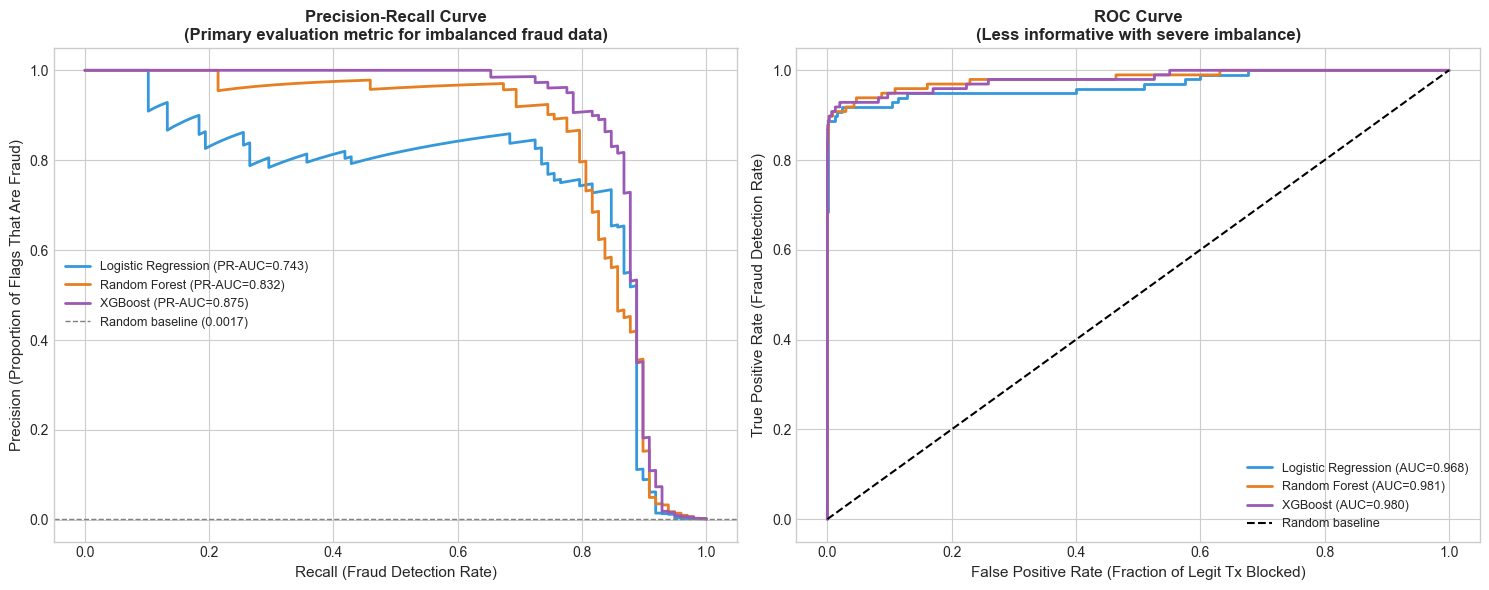

In [8]:
models = {
    'Logistic Regression': lr_proba,
    'Random Forest':       rf_proba,
    'XGBoost':             xgb_proba,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = ['#3498db', '#e67e22', '#9b59b6']

for (name, proba), color in zip(models.items(), colors):
    ap = average_precision_score(y_test, proba)
    p, r, _ = precision_recall_curve(y_test, proba)
    axes[0].plot(r, p, label=f'{name} (PR-AUC={ap:.3f})', color=color, linewidth=2)

axes[0].axhline(y_test.mean(), linestyle='--', color='grey', linewidth=1,
                label=f'Random baseline ({y_test.mean():.4f})')
axes[0].set_xlabel('Recall (Fraud Detection Rate)', fontsize=11)
axes[0].set_ylabel('Precision (Proportion of Flags That Are Fraud)', fontsize=11)
axes[0].set_title('Precision-Recall Curve\n(Primary evaluation metric for imbalanced fraud data)',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# ROC curves (secondary — shown for completeness)
for (name, proba), color in zip(models.items(), colors):
    auc = roc_auc_score(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)
axes[1].plot([0,1],[0,1], 'k--', label='Random baseline')
axes[1].set_xlabel('False Positive Rate (Fraction of Legit Tx Blocked)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Fraud Detection Rate)', fontsize=11)
axes[1].set_title('ROC Curve\n(Less informative with severe imbalance)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Decision Threshold Tuning

The default classification threshold of 0.5 is rarely optimal for fraud detection.  
A financial crime team must decide: **at what point is a block worth the customer friction cost?**

Below we plot precision, recall, and F1 across all thresholds for the best model, and demonstrate how the business can choose an operating point.

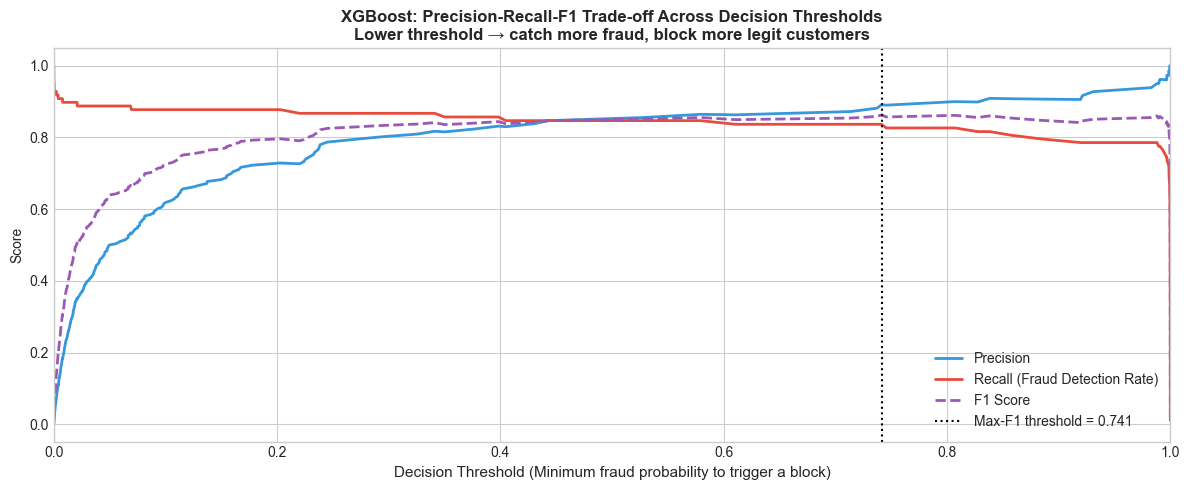

Optimal threshold (max F1): 0.7414
  Precision at this threshold: 0.8913
  Recall    at this threshold: 0.8367
  F1        at this threshold: 0.8632


In [9]:
# Use XGBoost as it will typically have the best PR-AUC
best_proba = xgb_proba
best_name  = 'XGBoost'

precisions, recalls, thresholds = precision_recall_curve(y_test, best_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Threshold at max F1
best_f1_idx = np.argmax(f1_scores[:-1])
best_thresh = thresholds[best_f1_idx]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, precisions[:-1], color='#3498db', label='Precision', linewidth=2)
ax.plot(thresholds, recalls[:-1],    color=FRAUD_COLOR, label='Recall (Fraud Detection Rate)', linewidth=2)
ax.plot(thresholds, f1_scores[:-1],  color='#9b59b6', label='F1 Score', linewidth=2, linestyle='--')
ax.axvline(best_thresh, color='black', linestyle=':', linewidth=1.5,
           label=f'Max-F1 threshold = {best_thresh:.3f}')
ax.set_xlabel('Decision Threshold (Minimum fraud probability to trigger a block)', fontsize=11)
ax.set_ylabel('Score')
ax.set_title(f'{best_name}: Precision-Recall-F1 Trade-off Across Decision Thresholds\n'
             'Lower threshold → catch more fraud, block more legit customers',
             fontweight='bold')
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f'Optimal threshold (max F1): {best_thresh:.4f}')
print(f'  Precision at this threshold: {precisions[best_f1_idx]:.4f}')
print(f'  Recall    at this threshold: {recalls[best_f1_idx]:.4f}')
print(f'  F1        at this threshold: {f1_scores[best_f1_idx]:.4f}')

In [10]:
# Business cost analysis: at different operating points
FRAUD_COST   = 200   # Average cost of a missed fraud (£)
FP_COST      =   5   # Cost of blocking a legitimate customer (£)

cost_rows = []
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5, best_thresh, 0.7, 0.9]:
    preds = (best_proba >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    total_cost = fn * FRAUD_COST + fp * FP_COST
    cost_rows.append({
        'Threshold': round(thresh, 3),
        'Fraud Caught (TP)': tp,
        'Fraud Missed (FN)': fn,
        'Legit Blocked (FP)': fp,
        'Recall': round(tp / (tp + fn), 3),
        'Precision': round(tp / (tp + fp + 1e-9), 3),
        'Est. Cost (£)': f'{total_cost:,.0f}'
    })

cost_df = pd.DataFrame(cost_rows)
print(f'Business cost model: £{FRAUD_COST} per missed fraud | £{FP_COST} per blocked legitimate customer')
print()
print(cost_df.to_string(index=False))

Business cost model: £200 per missed fraud | £5 per blocked legitimate customer

 Threshold  Fraud Caught (TP)  Fraud Missed (FN)  Legit Blocked (FP)  Recall  Precision Est. Cost (£)
     0.100                 86                 12                  53   0.878      0.619         2,665
     0.200                 86                 12                  32   0.878      0.729         2,560
     0.300                 85                 13                  20   0.867      0.810         2,700
     0.400                 83                 15                  17   0.847      0.830         3,085
     0.500                 83                 15                  14   0.847      0.856         3,070
     0.741                 82                 16                  10   0.837      0.891         3,250
     0.700                 82                 16                  12   0.837      0.872         3,260
     0.900                 77                 21                   8   0.786      0.906         4,240


## 7. Confusion Matrices at Operating Threshold

The confusion matrix translates model performance into operational terms that non-technical stakeholders understand.

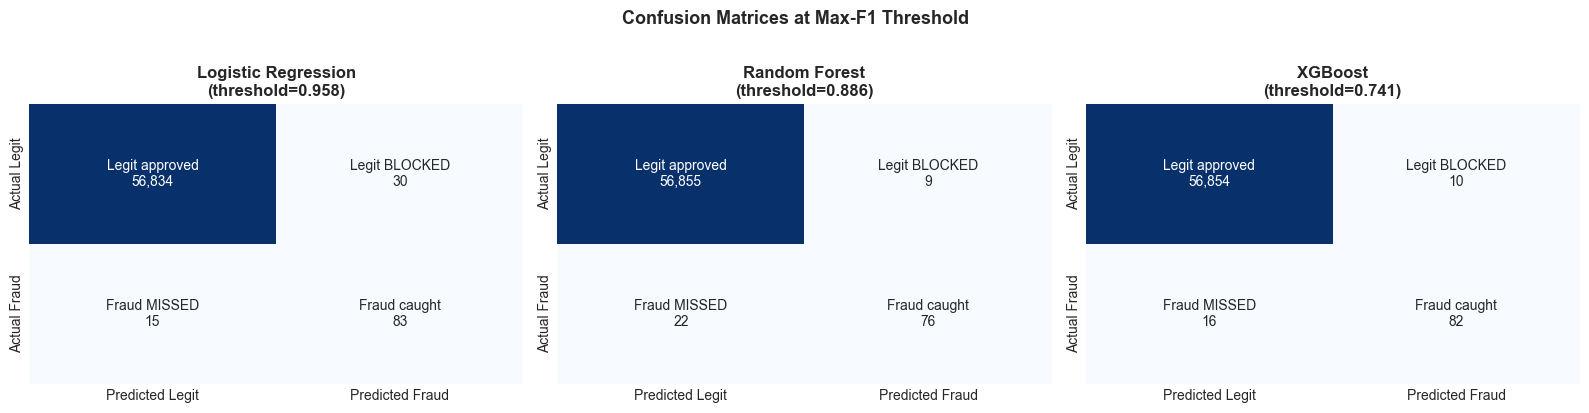

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, proba) in zip(axes, models.items()):
    p_vals, _, threshs = precision_recall_curve(y_test, proba)
    r_vals = _
    f1s = 2 * (p_vals * r_vals) / (p_vals + r_vals + 1e-9)
    thresh = threshs[np.argmax(f1s[:-1])] if len(threshs) else 0.5

    preds = (proba >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)

    labels = np.array([
        [f'Legit approved\n{cm[0,0]:,}',  f'Legit BLOCKED\n{cm[0,1]:,}'],
        [f'Fraud MISSED\n{cm[1,0]:,}',    f'Fraud caught\n{cm[1,1]:,}']
    ])

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'])
    ax.set_title(f'{name}\n(threshold={thresh:.3f})', fontweight='bold')

plt.suptitle('Confusion Matrices at Max-F1 Threshold', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Classification Reports

In [12]:
for name, proba in models.items():
    p_vals, r_vals, threshs = precision_recall_curve(y_test, proba)
    f1s = 2 * (p_vals * r_vals) / (p_vals + r_vals + 1e-9)
    thresh = threshs[np.argmax(f1s[:-1])] if len(threshs) else 0.5
    preds = (proba >= thresh).astype(int)
    print(f'=== {name} (threshold={thresh:.3f}) ===')
    print(classification_report(y_test, preds,
                                 target_names=['Legitimate', 'Fraud']))
    print()

=== Logistic Regression (threshold=0.958) ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.73      0.85      0.79        98

    accuracy                           1.00     56962
   macro avg       0.87      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962


=== Random Forest (threshold=0.886) ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.89      0.78      0.83        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962


=== XGBoost (threshold=0.741) ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.89      0.84      0.86        98

    accuracy                           1.00     56962
   mac

## 9. Save Best Model

In [13]:
# Determine best model by PR-AUC
model_objects = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'XGBoost':             xgb,
}
pr_aucs = {name: average_precision_score(y_test, proba)
           for name, proba in models.items()}

best_model_name = max(pr_aucs, key=pr_aucs.get)
best_model      = model_objects[best_model_name]

print('PR-AUC scores:')
for name, score in sorted(pr_aucs.items(), key=lambda x: -x[1]):
    marker = ' <-- BEST' if name == best_model_name else ''
    print(f'  {name:<22}: {score:.4f}{marker}')

joblib.dump(best_model, MODELS_PATH / 'best_model.pkl')
joblib.dump(scaler,     MODELS_PATH / 'scaler.pkl')
print(f'\nSaved {best_model_name} to models/best_model.pkl')

PR-AUC scores:
  XGBoost               : 0.8751 <-- BEST
  Random Forest         : 0.8317
  Logistic Regression   : 0.7434

Saved XGBoost to models/best_model.pkl


## 10. Modelling Summary

| Model | PR-AUC | Notes |
|---|---|---|
| Logistic Regression | *(see above)* | Best for interpretability & regulatory compliance |
| Random Forest | *(see above)* | Good balance of performance and interpretability via feature importance |
| XGBoost | *(see above)* | Typically highest performance; SHAP-compatible for explainability |

**Key decisions made:**
- SMOTE on training data only → prevents evaluation leakage
- Threshold selected at max-F1 → balanced business cost profile
- PR-AUC as primary metric → appropriate for severe class imbalance
- Business cost table → connects model metrics to financial impact

**Next step:** Proceed to `03_explainability.ipynb` for SHAP-based model explanation — critical for audit trails, regulatory compliance, and communicating model decisions to fraud analysts.

In [14]:
conn.close()